# 04 — Evaluation

This notebook loads the saved model and performs a thorough evaluation on the held-out test set: accuracy metrics, confusion matrix, classification report, error analysis, and per-class accuracy breakdown.

## Imports

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

2026-05-09 19:29:10.627251: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-09 19:29:11.096770: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-09 19:29:12.591731: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## Paths & Config

In [3]:
NOTEBOOK_DIR = Path.cwd()

BASE_DIR = NOTEBOOK_DIR.parent / "data"

TEST_DIR = BASE_DIR / "processed" / "test"

MODEL_PATH = NOTEBOOK_DIR.parent / "outputs" / "final_model.keras"
MAPPING_PATH = BASE_DIR / "metadata" / "class_mapping.json"

IMG_SIZE = 128
BATCH_SIZE = 64
SEED = 42

## Load Model & Class Mapping

In [4]:
model = tf.keras.models.load_model(MODEL_PATH)

with open(MAPPING_PATH, "r") as f:
    class_mapping = json.load(f)

class_names = list(class_mapping.values())

print("Model loaded:", MODEL_PATH)
print("Classes:", len(class_names))

2026-05-09 19:29:21.883736: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model loaded: /media/bakhom-ramzy/Windows E/A-university/Sem-2/img-processing/SignLanguageTranslator/SignLanguageTranslator/project/outputs/final_model.keras
Classes: 29


## Load Test Dataset

In [5]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 899 files belonging to 29 classes.


## Normalize Test Set

In [6]:
normalization = tf.keras.layers.Rescaling(1./255)

def preprocess(x, y):
    x = normalization(x)
    return x, y

test_ds = test_ds.map(preprocess)

## Run Predictions

In [7]:
y_true = []
y_pred = []

for images, labels in test_ds:

    preds = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions completed")

2026-05-09 19:29:52.084371: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 65028096 exceeds 10% of free system memory.
2026-05-09 19:29:52.175671: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 65028096 exceeds 10% of free system memory.
2026-05-09 19:29:52.315608: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 65028096 exceeds 10% of free system memory.
2026-05-09 19:29:52.402127: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 65028096 exceeds 10% of free system memory.
2026-05-09 19:29:52.557078: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 65028096 exceeds 10% of free system memory.


Predictions completed


2026-05-09 19:29:54.602951: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Overall Accuracy & Loss

In [8]:
loss, acc = model.evaluate(test_ds)

print("Test Accuracy:", acc)
print("Test Loss:", loss)

15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.9555 - loss: 0.1281 
Test Accuracy: 0.9555061459541321
Test Loss: 0.12806928157806396


## Confusion Matrix

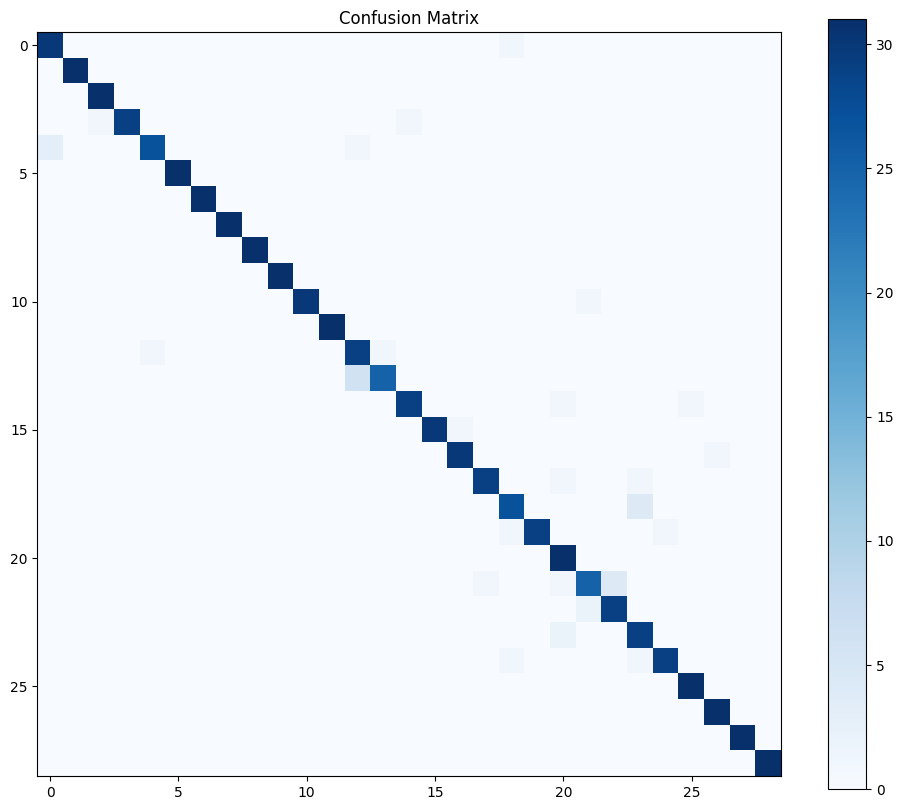

In [9]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

## Classification Report

In [10]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

              precision    recall  f1-score   support

           A       0.91      0.97      0.94        31
           B       1.00      1.00      1.00        31
           C       0.97      1.00      0.98        31
           D       1.00      0.94      0.97        31
           E       0.96      0.87      0.92        31
           F       1.00      1.00      1.00        31
           G       1.00      1.00      1.00        31
           H       1.00      1.00      1.00        31
           I       1.00      1.00      1.00        31
           J       1.00      1.00      1.00        31
           K       1.00      0.97      0.98        31
           L       1.00      1.00      1.00        31
           M       0.81      0.94      0.87        31
           N       0.96      0.81      0.88        31
           O       0.97      0.94      0.95        31
           P       1.00      0.97      0.98        31
           Q       0.97      0.97      0.97        31
           R       0.97    

## Report as DataFrame

In [11]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

df_report = pd.DataFrame(report_dict).transpose()
df_report

,precision,recall,f1-score,support
A,0.909091,0.967742,0.937500,31.000000
B,1.000000,1.000000,1.000000,31.000000
C,0.968750,1.000000,0.984127,31.000000
D,1.000000,0.935484,0.966667,31.000000
E,0.964286,0.870968,0.915254,31.000000
F,1.000000,1.000000,1.000000,31.000000
G,1.000000,1.000000,1.000000,31.000000
H,1.000000,1.000000,1.000000,31.000000
I,1.000000,1.000000,1.000000,31.000000
J,1.000000,1.000000,1.000000,31.000000


## Error Analysis

Count and rate of misclassified samples.

In [13]:
wrong_idx = np.where(y_true != y_pred)[0]

print("Total wrong predictions:", len(wrong_idx))
print("Error rate:", len(wrong_idx) / len(y_true))

Total wrong predictions: 40
Error rate: 0.04449388209121246


## Per-Class Accuracy

In [12]:
class_acc = {}

for i, cls in enumerate(class_names):

    idx = np.where(y_true == i)[0]

    acc_i = np.mean(y_pred[idx] == y_true[idx])

    class_acc[cls] = acc_i

pd.DataFrame.from_dict(class_acc, orient="index", columns=["accuracy"])

,accuracy
A,0.967742
B,1.000000
C,1.000000
D,0.935484
E,0.870968
F,1.000000
G,1.000000
H,1.000000
I,1.000000
J,1.000000
